# Train — ResNet-18

Trains and evaluates ResNet-18 using the tuned hyperparameters from `ARCH_HYPERPARAMS["resnet18"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["resnet18"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"ResNet-18: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders, same as every other architecture
# here -- its own (capped) batch size and image size, per cfg.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

ResNet-18: micro batch = 16, accumulation steps = 3 (effective batch size ≈ 48, tuned value = 48)


## Define the model (Transfer Learning with ResNet-18)

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with ResNet-18)
# ---------------------------------------------------------
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
in_f = model.fc.in_features
model.fc = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs, per the tuned step size.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[ResNet-18] Using gradient accumulation: 3 micro-batches per optimizer step (effective batch size ≈ micro_batch x 3).


Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190


Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
[ResNet-18] Epoch   1/100 | LR: 2.93e-04 | train loss 0.9019 acc 0.658 | val loss 0.6877 acc 0.695 *


Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190


Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
[ResNet-18] Epoch   2/100 | LR: 2.93e-04 | train loss 0.7211 acc 0.725 | val loss 0.8374 acc 0.616


...

Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
[ResNet-18] Epoch  29/100 | LR: 2.93e-05 | train loss 0.1314 acc 0.955 | val loss 0.4311 acc 0.842


Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190


Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
[ResNet-18] Epoch  30/100 | LR: 2.93e-05 | train loss 0.1136 acc 0.969 | val loss 0.4226 acc 0.842


Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190


Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
[ResNet-18] Epoch  31/100 | LR: 2.93e-05 | train loss 0.1392 acc 0.961 | val loss 0.4325 acc 0.845

[ResNet-18] No val loss improvement for 10 epochs — stopping early at epoch 31.

[ResNet-18] Restored be

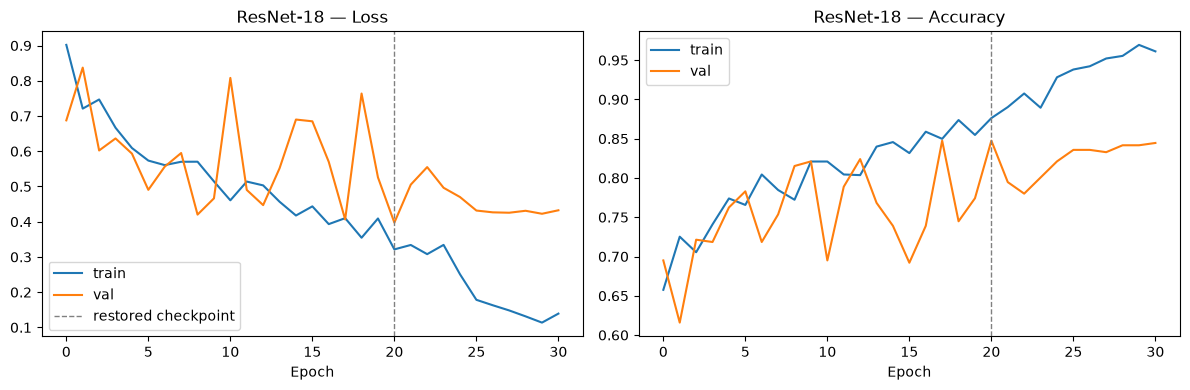

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "ResNet-18", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "ResNet-18")

## Evaluate on the test set

Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
[ResNet-18] Test accuracy: 0.821


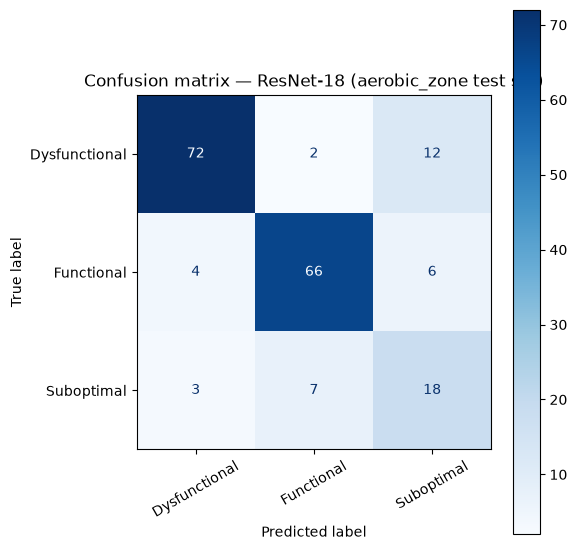

               precision    recall  f1-score   support

Dysfunctional      0.911     0.837     0.873        86
   Functional      0.880     0.868     0.874        76
   Suboptimal      0.500     0.643     0.562        28

     accuracy                          0.821       190
    macro avg      0.764     0.783     0.770       190
 weighted avg      0.838     0.821     0.828       190



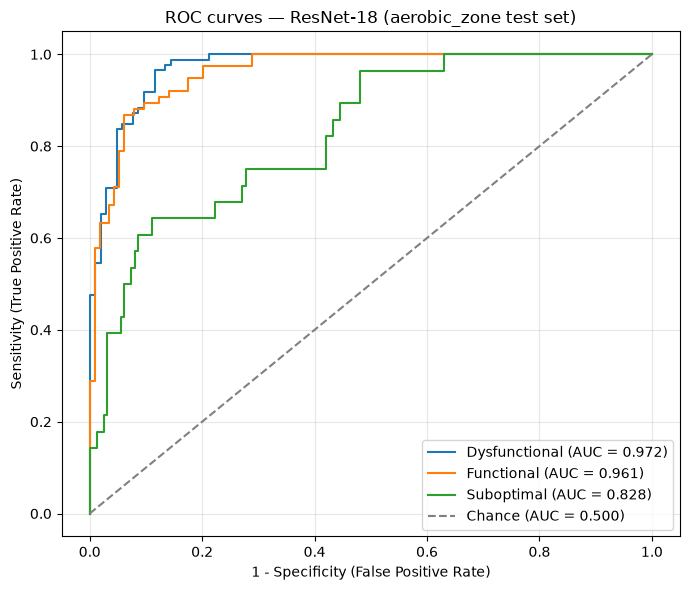

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.972
  Functional     : 0.961
  Suboptimal     : 0.828

Mean AUC (over 3/3 classes with test examples): 0.920


(np.float64(0.8210526315789474),
 {'Dysfunctional': 0.9716010733452594,
  'Functional': 0.9611034164358264,
  'Suboptimal': 0.8284832451499118})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "ResNet-18", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

This is the step the results notebook depends on — it pickles the metrics/history and saves the model state dict so nothing needs to be kept in memory or re-trained.

In [6]:
save_result("ResNet-18", "resnet18")

Saved results to ../results/aerobic_zone_pad_aug/results_aerobic_zone_resnet18_stratified.pkl


Saved model weights to ../models/pad/aerobic_zone_resnet18_cnn.pt
